In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
Internationale_Stu_16_23= pd.read_csv(r"C:\Users\maria\OneDrive\Desktop\PerDekumente\JLU-Data Science\Semester-2\Informationsvisualisierung\Projekt\Neuer Ordner\Neuer Ordner\Projekt\data_excels\Ausländische Studierende\Ausländische Studierende.csv", sep=";")
Internationale_Stu_24_25= pd.read_csv(r"C:\Users\maria\OneDrive\Desktop\PerDekumente\JLU-Data Science\Semester-2\Informationsvisualisierung\Projekt\wise24 - wise25\wise24 - wise25\ausländische_Studierende_Köpfe.csv")

In [5]:
# Zusammenführen
Internationale_Stu_2016_2025= pd.concat([Internationale_Stu_16_23, Internationale_Stu_24_25])
Internationale_Stu_2016_2025 =Internationale_Stu_2016_2025.sort_values(by=["Jahr", "Semester"])

In [7]:
# Studienfächer bereinigen
Internationale_Stu_2016_2025["Studienfach_clean"] = Internationale_Stu_2016_2025["Studienfach"].replace({
    "Informatik": "Informatik", "informatik":"Informatik", "Data Science/Informatik":"Data Science",
    "Data Sc./Data Analyt./Informatik": "Data Science", "data analytics": "Data Science","data science": "Data Science","mathematik":"Mathematik",
    'Liberal Arts and Sciences': 'Liberal Arts and Sciences','Geograph./Erdk.': 'Geographie','geographie':'Geographie',
    'physik':'Physik','Physik': 'Physik'
    })

In [9]:
df_pivot = Internationale_Stu_2016_2025.pivot_table(
    index="Jahr",
    columns="Studienfach_clean",
    values="Summe_Koepfe",
    aggfunc="sum"  # falls mehrere Einträge pro Jahr+Studienfach
)

In [11]:
# Fill NaN with linear interpolatin
df_pivot= df_pivot.sort_index().interpolate(method="linear").ffill().bfill()
subjects_to_fix = ['Mathematik', 'Physik', 'Geographie', 'Informatik']
for subject in subjects_to_fix:
    avg_val = (df_pivot.loc[2023, subject] + df_pivot.loc[2025, subject]) / 2
    df_pivot.loc[2024, subject] = avg_val

In [13]:
df_pivot = df_pivot.drop(columns=['Gesamt'], errors='ignore')
df_pivot['Gesamt'] = df_pivot.sum(axis=1)

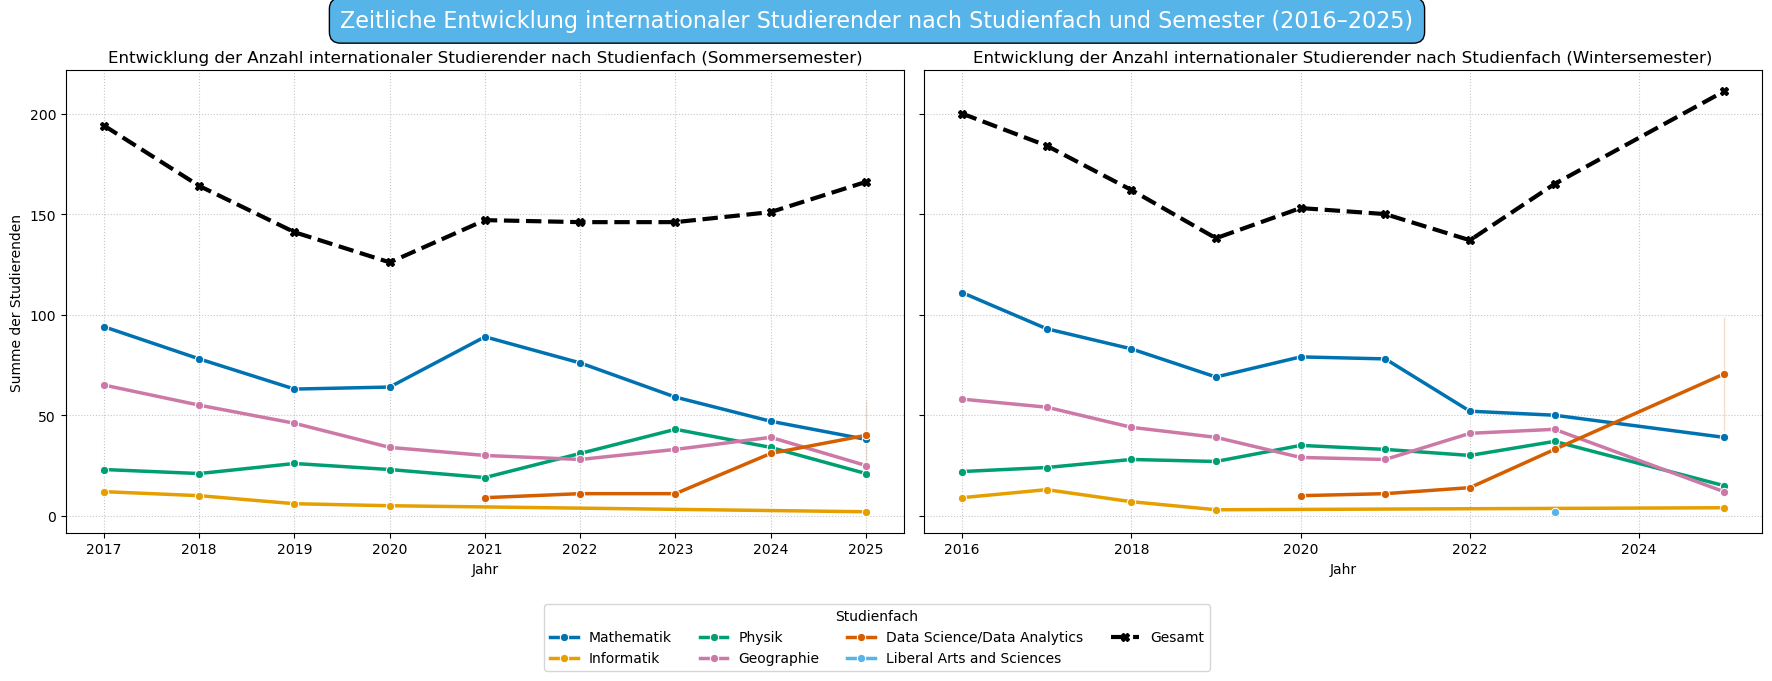

In [19]:
# Daten vorbereiten
df_long_semester = Internationale_Stu_2016_2025.copy()

# Subplots erstellen
fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

# Semester festlegen (Reihenfolge)
semester_list = ["Sommer", "Winter"]

# Farben
faecher = df_long_semester["Studienfach_clean"].unique()
base_colors = [
    "#0072B2", "#E69F00", "#009E73",
    "#CC79A7", "#D55E00", "#56B4E9",
    "#F0E442", "#000000"
]

palette_dict = {
    fach: base_colors[i % len(base_colors)]
    for i, fach in enumerate(faecher)
}

# Schleife für beide Subplots
for ax, semester in zip(axes, semester_list):

    df_sem = df_long_semester[df_long_semester["Semester"] == semester]

    sns.lineplot(
        data=df_sem,
        x="Jahr",
        y="Summe_Koepfe",
        hue="Studienfach_clean",
        hue_order=faecher,
        palette=palette_dict,
        marker="o",
        linewidth=2.5,
        ax=ax
    )

    ax.legend(
        labels=["Mathematik", "Physik", "Geographie", "Data Science/Data Analytics", ...], 
        title="Studienfach"
    )
    
    df_total_sem = df_sem.groupby("Jahr", as_index=False)["Summe_Koepfe"].sum()

    ax.plot(
        df_total_sem["Jahr"],
        df_total_sem["Summe_Koepfe"],
        marker="X",
        linewidth=3,
        linestyle="--",
        color="black",
        label="Gesamt"
    )

    ax.set_title(f"Entwicklung der Anzahl internationaler Studierender nach Studienfach ({semester}semester)")
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Summe der Studierenden")
    ax.grid(True, linestyle=":", alpha=0.7)

# Legende
handles, labels = axes[1].get_legend_handles_labels()

labels = ["Data Science/Data Analytics" if lbl == "Data Science" else lbl for lbl in labels]

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=4,
    title="Studienfach"
)

fig.suptitle(
    "Zeitliche Entwicklung internationaler Studierender nach Studienfach und Semester (2016–2025)",
    fontsize=16,
    color="white",
    bbox=dict(
        facecolor="#56B4E9",
        edgecolor="black",
        boxstyle="round,pad=0.5"
    )
)

for ax in axes:
    ax.get_legend().remove()

plt.tight_layout(rect=[0.01, 0.01, 1, 1])

plt.show()

## Bildbeschreibung
Die Gesamtzahl der internationalen Studierenden ist zunächst bis etwa 2020 rückläufig, anschließend jedoch wieder ansteigt und bis 2025 ihr höchstes Niveau erreicht. Bei der fachspezifischen Betrachtung zeigen sich deutliche Unterschiede: Mathematik weist über den gesamten Zeitraum hinweg vergleichsweise hohe Werte auf, zeigt jedoch einen leicht abnehmenden Trend. Physik bewegt sich im mittleren Bereich und bleibt relativ stabil, mit leichten Schwankungen. Geographie/Erdkunde zeigt tendenziell sinkende Werte im Zeitverlauf. Informatik bleibt zunächst auf niedrigem Niveau, steigt jedoch in den späteren Jahren moderat an. Besonders auffällig ist der starke Anstieg im Bereich Data Science, der vor allem ab etwa 2022 deutlich zunimmt und bis 2025 stark wächst.Für Liberal Arts and Sciences liegt nur ein einzelner Datenpunkt vor, sodass keine Entwicklung im Zeitverlauf interpretiert werden kann.Ein Vergleich zwischen Sommer- und Wintersemester zeigt, dass die Werte im Wintersemester in der Regel höher sind als im Sommersemester.In einigen Studiengängen, insbesondere Informatik, liegen für bestimmte Jahre (2021-2024)keine Daten vor. Diese wurden mithilfe linearer Interpolation geschätzt, um eine durchgehende Zeitreihe darzustellen. Die interpolierten Werte sind daher mit Vorsicht zu interpretieren.....Die Unterschiede fallen je nach Studiengang unterschiedlich stark aus. Zudem ist im Zeitraum von etwa 2020 bis 2022 ein leichter Rückgang bzw. eine Stagnation in mehreren Studiengängen zu erkennen, was vermutlich auf die Auswirkungen der COVID-19-Pandemie zurückzuführen ist.

## Sprechtext
Die vorliegende Folie veranschaulicht die zeitliche Entwicklung der Anzahl internationaler Studierender nach Studienfach im Zeitraum von 2016 bis 2025. Dabei wird zwischen Sommer- und Wintersemester unterschieden, die in zwei separaten Grafiken dargestellt sind.

Zunächst lässt sich erkennen, dass die Gesamtzahl der internationalen Studierenden in beiden Semestern bis etwa zum Jahr 2020 deutlich zurückgeht. Danach ist jedoch eine Erholung zu beobachten, sodass die Zahlen bis 2025 wieder ansteigen. Ein besonders auffälliger Aspekt ist der saisonale Unterschied zwischen den Semestern. Insgesamt ist deutlich zu erkennen, dass im Wintersemester durchgehend mehr internationale Studierende eingeschrieben sind als im Sommersemester. Dies lässt sich vermutlich dadurch erklären, dass das Wintersemester als Hauptsemester gilt und mehr Studienplätze sowie Zulassungsmöglichkeiten bietet oder Internationale Studierende oft Visa, Sprachtests oder Anerkennungen von Zeugnissen erledigen müssen. Viele schaffen dies rechtzeitig für das Wintersemester, das zeitlich nach den meisten Schul- oder Bachelorabschlüssen liegt.

Betrachtet man die einzelnen Studienfächer genauer, so zeigt sich, dass Mathematik zu Beginn den größten Anteil aufweist, jedoch im Verlauf der Jahre kontinuierlich an Bedeutung verliert. Ein ähnlicher, wenn auch weniger ausgeprägter Trend ist in der Geographie zu erkennen.

Im Gegensatz dazu weist der Studiengang Data Science, der Data Science und Data Analytics representiert, einen besonders starken Anstieg auf, vor allem ab dem Jahr 2021. Dies deutet darauf hin, dass datenorientierte Studiengänge zunehmend an Attraktivität gewinnen. Die Physik zeigt hingegen moderate Schwankungen mit einer leicht steigenden Tendenz, während Informatik relativ stabil bleibt.

Zusammenfassend lässt sich sagen, dass neben einem allgemeinen Strukturwandel hin zu modernen Studienfächern auch ein klarer saisonaler Effekt besteht: Das Wintersemester spielt eine zentrale Rolle für internationale Studierende, da hier die höchsten Einschreibezahlen erreicht werden. Die zunehmende Zahl internationaler Studierender zeigt, dass die Universität nicht nur immer stärker international wahrgenommen wird, was den interkulturellen Austausch und die Vielfalt im Studium fördert, sondern zugleich auch ihre Position in globalen Hochschulrankings verbessern kann.

Abschließend könnte man sich fragen, wie Universitäten ihre Kapazitäten im Wintersemester ausbauen können, um genug passend Studiepläze anbieten zu können. Gleichzeitig zeigt der starke Anstieg in zukunftsorientierten Studiengängen wie Data Science, dass internationale Studierende zunehmend von attraktiven und praxisnahen Angeboten angezogen werden.

## Warum haben wir diese Variable ausgewählt?
Die Anzahl internationaler Studierender ist eine zentrale Kennzahl für: • Internationalisierungsstrategien • Hochschulranking • politische und akademische Planung • Unterschiede zwischen Sommer- und Wintersemester • welche Fächer besonders beliebt sind (z. B. Informatik, Data Science) • wo weniger Nachfrage besteht Das hilft bei: • Kapazitätsplanung • Entwicklung neuer Studienprogramme